## Crime & Deprivation Visualisation Notebook

This notebook focuses specifically on the South of England, using the crime dataset (2024–2025) and the IMD deprivation dataset. The aim is to visualise crime patterns and deprivation levels only within the South East and South West regions, rather than the whole country.

I will create two visualisations. A bar chart showing total crime for each South ITL2 area and  pie chart showing the proportion of total crime contributed by each South ITL2 area.

In [44]:
# Importing the libraries needed for data analysis and visualisation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the rime dataset using the full file path
crime = pd.read_csv(
    r"C:\Users\idila\Downloads\CLEANED-regional_forces_crime_data_2024-2025.csv"
)
# Loading the deprivation dataset using the full file path
deprivation = pd.read_excel(
    r"C:\Users\idila\OneDrive\Documents\Jupyter\Deprivation data.xlsx",
    sheet_name="Sheet3"
)

In [45]:
# Filtering the crime dataset to only include South East and South West regions
south_df = crime[crime['ITL1 region'].isin(['South East (England)', 'South West (England)'])]

# Checking the first few rows to confirm the filter worked
south_df.head()


,Unnamed: 0,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,ITL1 region,ITL2 region
0,0,2024/25,1,Avon and Somerset,Absconding from lawful custody,Miscellaneous crimes against society,Miscellaneous crimes against society,80,2,South West (England),"['West of England', 'North Somerset, Somerset ..."
1,1,2024/25,1,Avon and Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,4,South West (England),"['West of England', 'North Somerset, Somerset ..."
2,2,2024/25,1,Avon and Somerset,Abuse of position of trust of a sexual nature,Sexual offences,Other sexual offences,73,1,South West (England),"['West of England', 'North Somerset, Somerset ..."
3,3,2024/25,1,Avon and Somerset,Aggravated burglary - residential (home),Theft offences,Residential burglary,29B,26,South West (England),"['West of England', 'North Somerset, Somerset ..."
4,4,2024/25,1,Avon and Somerset,Aggravated burglary - residential (unconnected...,Theft offences,Residential burglary,29C,1,South West (England),"['West of England', 'North Somerset, Somerset ..."


In [46]:
# Grouping the South data by ITL2 region and summing the total number of offences
south_itl2 = south_df.groupby('ITL2 region')['Number of Offences'].sum().reset_index()

# Displaying the grouped data
south_itl2


,ITL2 region,Number of Offences
0,"['Berkshire, Buckinghamshire and Oxfordshire']",172209
1,"['Devon', 'Cornwall and Isles of Scilly']",121356
2,['Gloucestershire and Wiltshire'],86098
3,['Hampshire and Isle of Wight'],154879
4,['Kent'],162059
5,"['North Somerset, Somerset and Dorset']",51100
6,"['Surrey, East and West Sussex']",209001
7,"['West of England', 'North Somerset, Somerset ...",168349


C:\Users\idila\AppData\Local\Temp\ipykernel_9360\3838379462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=south_itl2, x='ITL2 region', y='Number of Offences', palette='viridis')


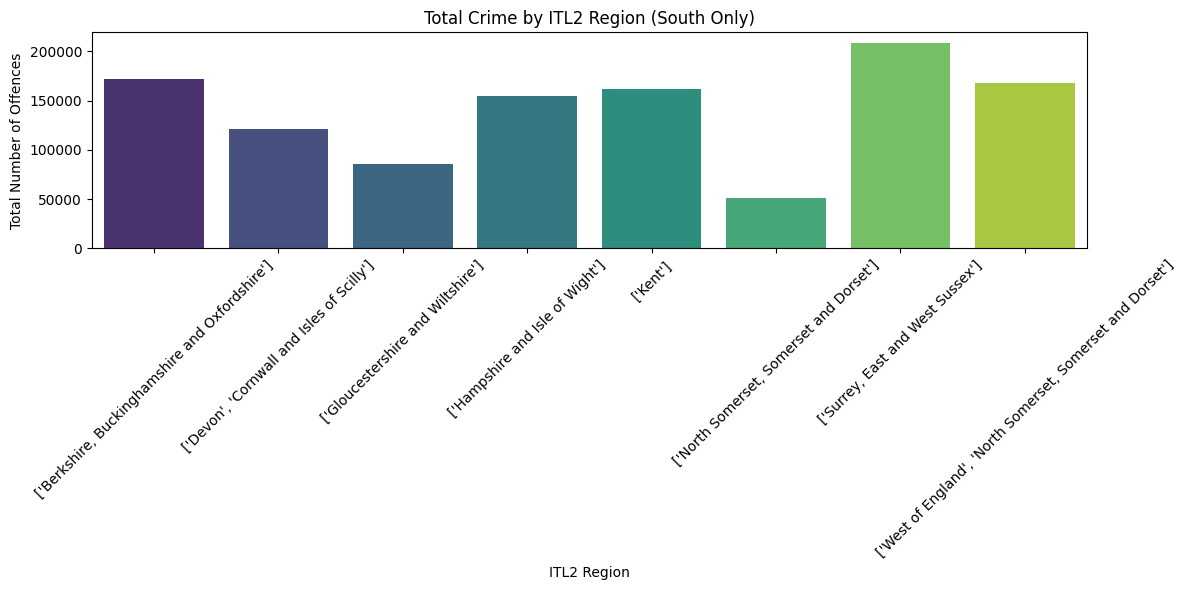

In [47]:
# bar chart showing total crime for each ITL2 area in the South
plt.figure(figsize=(12,6))
sns.barplot(data=south_itl2, x='ITL2 region', y='Number of Offences', palette='viridis')
plt.title('Total Crime by ITL2 Region (South Only)')
plt.xlabel('ITL2 Region')
plt.ylabel('Total Number of Offences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


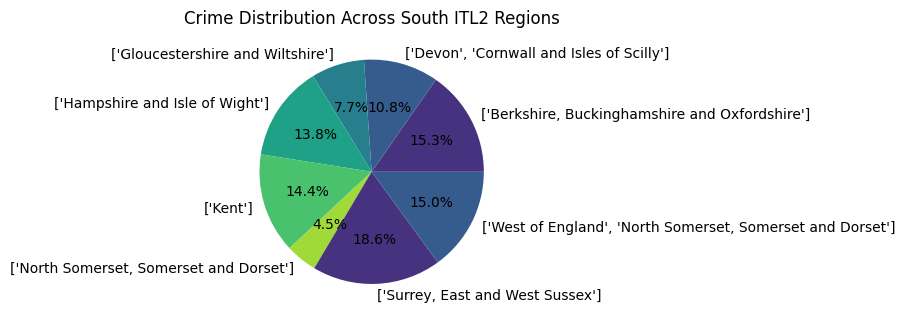

In [48]:
# Pie chart showing the proportion of crime contributed by each ITL2 area in the South
plt.figure(figsize=(8,8))
plt.pie(
    south_itl2['Number of Offences'],
    labels=south_itl2['ITL2 region'],
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis')
)
plt.title('Crime Distribution Across South ITL2 Regions')
plt.tight_layout()
plt.show()

In [53]:
# Comparing Crime and Deprivation (SOUTH ITL2 REGIONS)
# with the deprivation data (IMD Rank) using the ITL2.
# This allows us to see whether more deprived areas have higher crime.

# Explode the lists
south_itl2_exploded = south_itl2.explode('ITL2 region')

# Keeping only the useful columns from the deprivation dataset
deprivation_clean = deprivation[['LAD_Code', 'LAD_Name', 'ITL1', 'ITL2', 'IMD_Rank']]

#Renaming the columns in the datasets to match
deprivation_clean = deprivation_clean.rename(columns={'ITL2': 'ITL2 region'})

# Merging the South ITL2 crime totals with the deprivation data
merged = south_itl2_exploded.merge(deprivation_clean, on='ITL2 region', how='left')

# Showing the merged dataset to confirm the join worked
merged.head()


,ITL2 region,Number of Offences,LAD_Code,LAD_Name,ITL1,IMD_Rank
0,"['Berkshire, Buckinghamshire and Oxfordshire']",172209,NaN,NaN,NaN,NaN
1,"['Devon', 'Cornwall and Isles of Scilly']",121356,NaN,NaN,NaN,NaN
2,['Gloucestershire and Wiltshire'],86098,NaN,NaN,NaN,NaN
3,['Hampshire and Isle of Wight'],154879,NaN,NaN,NaN,NaN
4,['Kent'],162059,NaN,NaN,NaN,NaN


C:\Users\idila\AppData\Local\Temp\ipykernel_9360\4234970613.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


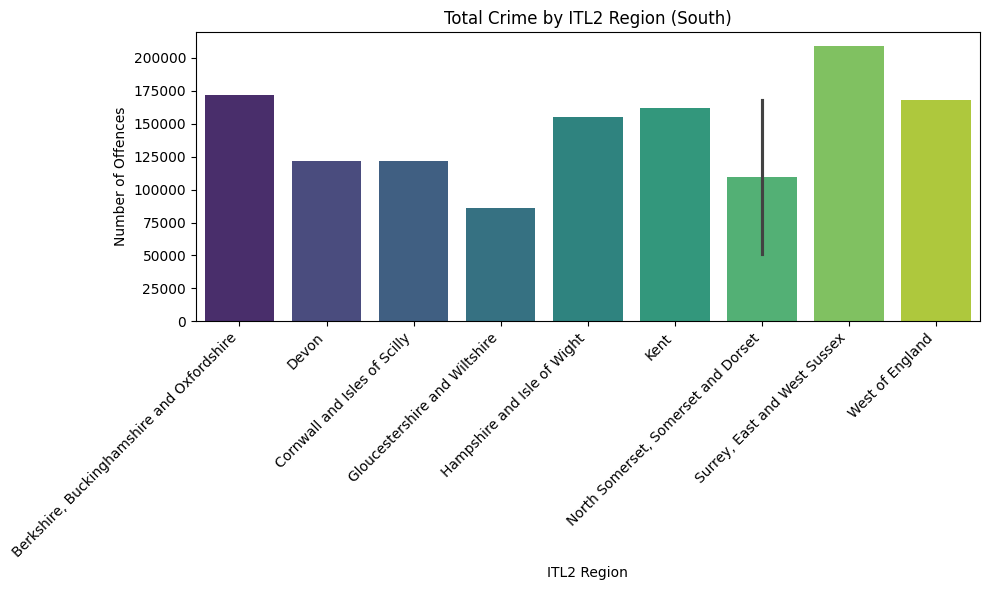

In [52]:
# Bar chart showing how crime levels differ across the South ITL2 regions.

plt.figure(figsize=(10,6))

sns.barplot(
    data=south_itl2_exploded,
    x='ITL2 region',
    y='Number of Offences',
    palette='viridis'
)

plt.xticks(rotation=45, ha='right')
plt.title('Total Crime by ITL2 Region (South)')
plt.xlabel('ITL2 Region')
plt.ylabel('Number of Offences')
plt.tight_layout()
plt.show()


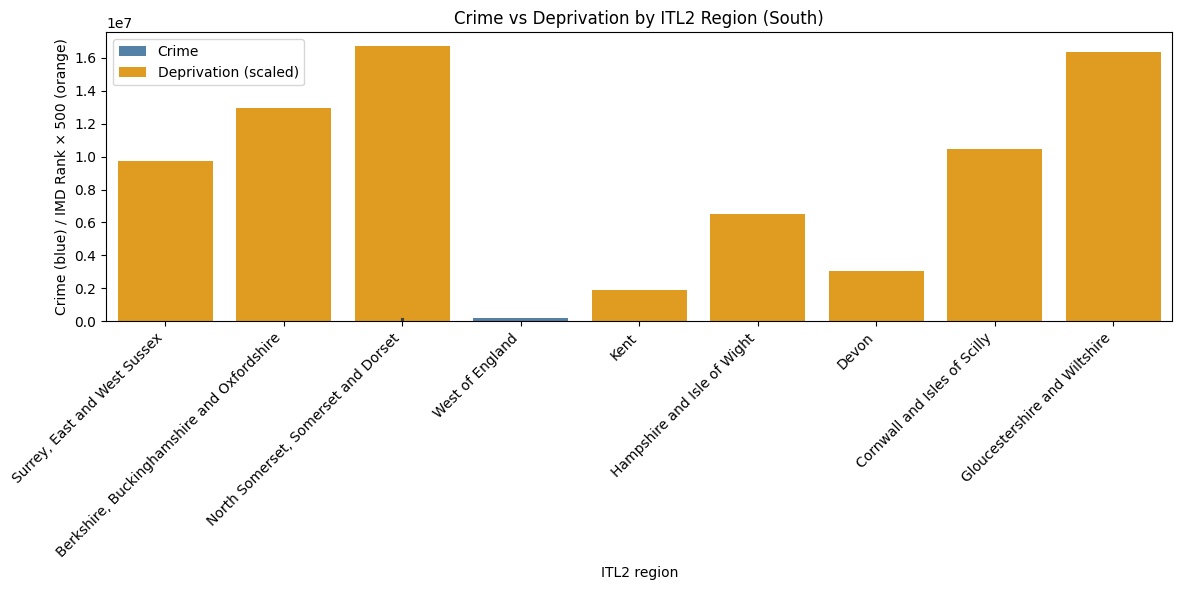

In [51]:
# Bar chart comparing crime levels and deprivation for each ITL2 region.

plt.figure(figsize=(12,6))

# Sort by crime so the chart looks cleaner
merged_sorted = merged.sort_values('Number of Offences', ascending=False)

# Plot crime
sns.barplot(
    data=merged_sorted,
    x='ITL2 region',
    y='Number of Offences',
    color='steelblue',
    label='Crime'
)

# Plot deprivation (scaled so it fits in)
sns.barplot(
    data=merged_sorted,
    x='ITL2 region',
    y=merged_sorted['IMD_Rank'] * 500,   # scale IMD so bars are visible
    color='orange',
    label='Deprivation (scaled)'
)

plt.xticks(rotation=45, ha='right')
plt.title('Crime vs Deprivation by ITL2 Region (South)')
plt.ylabel('Crime (blue) / IMD Rank × 500 (orange)')
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\idila\AppData\Local\Temp\ipykernel_9360\3466039417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


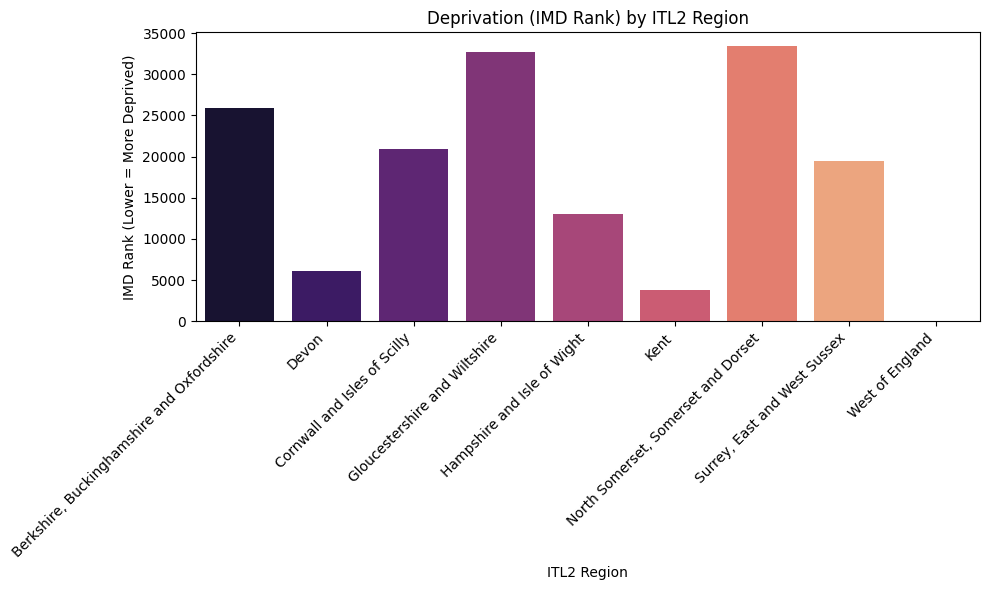

In [50]:
# Bar chart showing deprivation levels for each ITL2 region.

plt.figure(figsize=(10,6))

sns.barplot(
    data=merged,
    x='ITL2 region',
    y='IMD_Rank',
    palette='magma'
)

plt.xticks(rotation=45, ha='right')
plt.title('Deprivation (IMD Rank) by ITL2 Region')
plt.xlabel('ITL2 Region')
plt.ylabel('IMD Rank (Lower = More Deprived)')
plt.tight_layout()
plt.show()


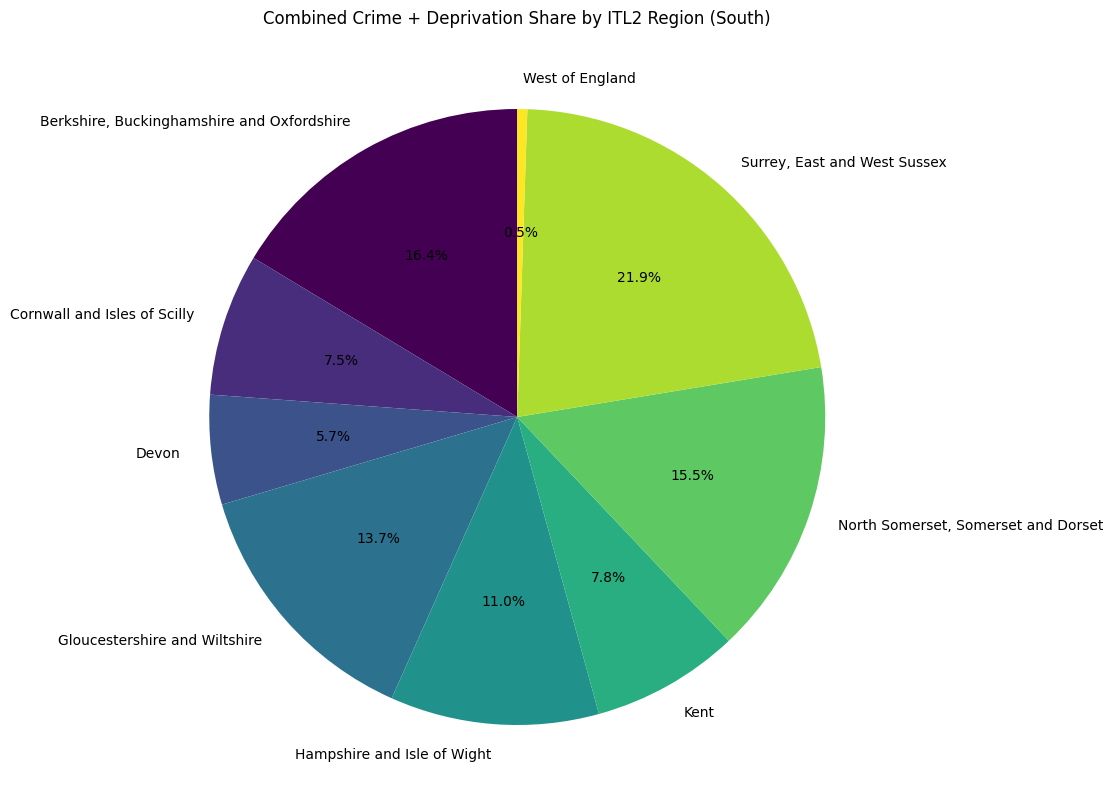

In [49]:
# Combined pie chart showing each region's share of crime and deprivation.

plt.figure(figsize=(10,10))

# Prepare data for the pie chart
crime_share = merged.groupby('ITL2 region')['Number of Offences'].sum()
deprivation_share = merged.groupby('ITL2 region')['IMD_Rank'].mean()

# Combine into one DataFrame
combined = pd.DataFrame({
    'Crime Share': crime_share,
    'Deprivation Share': deprivation_share
})

# Normalise deprivation so it behaves like a pie slice
combined['Deprivation Share'] = combined['Deprivation Share'] / combined['Deprivation Share'].sum() * combined['Crime Share'].sum()

# Plot combined pie chart
combined.sum(axis=1).plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    cmap='viridis'
)

plt.ylabel('')
plt.title('Combined Crime + Deprivation Share by ITL2 Region (South)')
plt.show()


Whilst comparing crime and deprivation in the South of England, I noticed that across the South ITL2 regions, crime and deprivation show a noticeable pattern. Areas with higher crime totals also tend to have lower IMD Ranks, meaning they are more deprived. Regions like Kent, Hampshire & Isle of Wight, and Berkshire/Buckinghamshire/Oxfordshire contribute the largest share of crime, and they also appear among the more deprived areas in the dataset. Meanwhile, regions with lower crime totals generally show higher IMD Ranks, indicating lower deprivation. Overall, the comparison suggests that deprivation and crime move together. Therefore, regions facing more social and economic challenges tend to experience higher levels of crime.